# Solar Composition


This notebook reproduces the Solar Composition figure used in the paper. We compare the default solar composition with a mixture scaled to twice the default solar metallicity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pynucastro.nucdata import SolarComposition, Nucleus

Compute the total hydrogen, helium, and metal mass fractions:

In [2]:
def xyz_from_comp(comp):
    X = 0.0
    Y = 0.0
    Z = 0.0

    for nuc, X_i in comp.items():
        if nuc.Z == 1:
            X += X_i
        elif nuc.Z == 2:
            Y += X_i
        else:
            Z += X_i

    return X, Y, Z

Some formatting for isotope names for plotting:

In [3]:
def isotope_label(nuc):
    if nuc == Nucleus("p") or nuc.raw == "h1":
        return r"$^1\mathrm{H}$"
    return rf"$^{{{nuc.A}}}\mathrm{{{nuc.el.capitalize()}}}$"

Now construct the default solar composition and a second composition with twice the default solar metallicity:

In [4]:
solar = SolarComposition()
X_solar, Y_solar, Z_solar = xyz_from_comp(solar)

two_x = SolarComposition(Z=2.0 * Z_solar)
X_two, Y_two, Z_two = xyz_from_comp(two_x)

print(f"default solar metallicity: Z = {Z_solar:.10f}")
print(f"twice solar metallicity:     Z = {Z_two:.10f}")

default solar metallicity: Z = 0.0149641587
twice solar metallicity:     Z = 0.0299283174


Find the most abundant metal isotopes from the default composition:

In [5]:
n_top_metals = 6

metal_items = [
    (nuc, x)
    for nuc, x in solar.items()
    if nuc.Z > 2
]

metal_items.sort(key=lambda item: item[1], reverse=True)
metal_nuclei = [nuc for nuc, _ in metal_items[:n_top_metals]]

for nuc in metal_nuclei:
    print(f"{nuc}: X = {solar[nuc]:.6e}")

O16: X = 6.361736e-03
C12: X = 2.595892e-03
Ne20: X = 1.949919e-03
Fe56: X = 1.073955e-03
N14: X = 7.313696e-04
Si28: X = 6.179743e-04


Finally, the plotting:

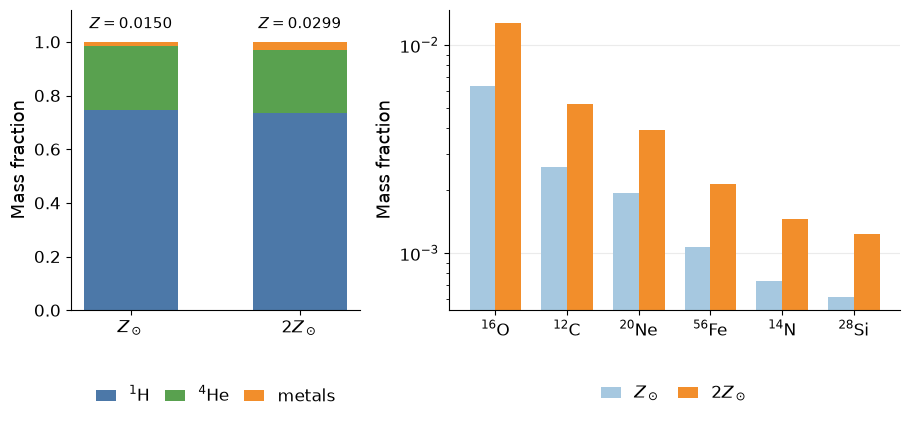

In [6]:
FS_TITLE = 15
FS_LABEL = 13
FS_TICK = 12
FS_LEGEND = 12
FS_ANNOT = 11

colors = {
    "H": "#4C78A8",
    "He": "#59A14F",
    "metals": "#F28E2B",
    "solar": "#A6C8E0",
    "twox": "#F28E2B",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.4),
    gridspec_kw={"width_ratios": [0.9, 1.4]},
)

labels = [r"$Z_\odot$", r"$2Z_\odot$"]
x = np.arange(len(labels))

H_vals = np.array([X_solar, X_two])
He_vals = np.array([Y_solar, Y_two])
Z_vals = np.array([Z_solar, Z_two])

bar_width = 0.56

axes[0].bar(x, H_vals, width=bar_width, color=colors["H"], label=r"$^1\mathrm{H}$")
axes[0].bar(x, He_vals, width=bar_width, bottom=H_vals, color=colors["He"], label=r"$^4\mathrm{He}$")
axes[0].bar(x, Z_vals, width=bar_width, bottom=H_vals + He_vals, color=colors["metals"], label="metals")

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.0, 1.12)
axes[0].set_ylabel("Mass fraction", fontsize=FS_LABEL)

for i, zval in enumerate(Z_vals):
    axes[0].text(
        x[i],
        1.035,
        rf"$Z={zval:.4f}$",
        ha="center",
        va="bottom",
        fontsize=FS_ANNOT,
    )

axes[0].legend(
    frameon=False,
    fontsize=FS_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=3,
    handlelength=1.2,
    columnspacing=0.9,
)

solar_metals = np.array([solar[nuc] for nuc in metal_nuclei])
two_x_metals = np.array([two_x[nuc] for nuc in metal_nuclei])

mx = np.arange(len(metal_nuclei))
w = 0.36

axes[1].bar(mx - w / 2, solar_metals, width=w, label=r"$Z_\odot$", color=colors["solar"])
axes[1].bar(mx + w / 2, two_x_metals, width=w, label=r"$2Z_\odot$", color=colors["twox"])

axes[1].set_xticks(mx)
axes[1].set_xticklabels(
    [isotope_label(nuc) for nuc in metal_nuclei],
    ha="center",
    rotation_mode="anchor",
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Mass fraction", fontsize=FS_LABEL)
axes[1].legend(
    frameon=False,
    fontsize=FS_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    handlelength=1.2,
    columnspacing=1.0,
)

axes[1].grid(axis="y", which="major", alpha=0.25, linewidth=0.8)
axes[1].set_axisbelow(True)

for ax in axes:
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("solar-comp.pdf", bbox_inches="tight")